# 📚 Knowledge Base RAG Chatbot with Text-to-Speech

This notebook builds a **Retrieval-Augmented Generation (RAG)** chatbot that:
- Loads a PDF knowledge base (e.g., an HR manual)
- Splits and embeds the content into a local vector store (ChromaDB)
- Answers questions using a Groq-hosted LLM (LLaMA 3)
- Speaks responses aloud using **Google Text-to-Speech (gTTS)** — natural, high-quality voice

**Stack:** LangChain · ChromaDB · HuggingFace Embeddings · Groq · gTTS

---
## ⚙️ Step 0 — Install Dependencies

In [1]:
# Install all required packages in one shot
# - langchain*         : RAG pipeline components and integrations
# - chromadb           : fast local vector store for semantic search
# - sentence-transformers : HuggingFace local embeddings (no OpenAI key needed)
# - pypdf              : PDF page loading
# - langchain_groq     : Groq LLM integration (free, fast inference)
# - gtts               : Google Text-to-Speech — natural voice, no API key needed
%pip install -q \
    langchain langchain-community langchain-core langchain-chroma langchain-groq \
    pypdf sentence-transformers chromadb \
    gtts

Note: you may need to restart the kernel to use updated packages.


---
## 🔑 Step 1 — Configuration

> Store your **Groq API key** in Colab Secrets (left sidebar → 🔑 icon → name it `Groq`).  
> Get a free key at https://console.groq.com

In [2]:
pip install python -dotenv

Note: you may need to restart the kernel to use updated packages.



Usage:   
  c:\Users\asus\anaconda3\python.exe -m pip install [options] <requirement specifier> [package-index-options] ...
  c:\Users\asus\anaconda3\python.exe -m pip install [options] -r <requirements file> [package-index-options] ...
  c:\Users\asus\anaconda3\python.exe -m pip install [options] [-e] <vcs project url> ...
  c:\Users\asus\anaconda3\python.exe -m pip install [options] [-e] <local project path> ...
  c:\Users\asus\anaconda3\python.exe -m pip install [options] <archive url/path> ...

no such option: -d


In [3]:
import os
from getpass import getpass

# Try env var first, otherwise prompt securely
GROQ_API_KEY = os.environ.get('GROQ_API_KEY')
if not GROQ_API_KEY:
    GROQ_API_KEY = getpass("Enter GROQ_API_KEY (hidden): ")
os.environ['GROQ_API_KEY'] = GROQ_API_KEY

# Local PDF path (update to your actual file)
PDF_PATH = ''

# RAG settings
CHUNK_SIZE    = 1000
CHUNK_OVERLAP = 100
TOP_K         = 4
EMBED_MODEL   = 'all-MiniLM-L6-v2'
LLM_MODEL     = 'llama-3.1-8b-instant'

# TTS settings
TTS_LANGUAGE = 'en'
TTS_SLOW     = False

print('✅ Configuration loaded.')

✅ Configuration loaded.


---
## 📄 Step 2 — Load & Chunk the PDF

In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Load every page of the PDF as a LangChain Document object
loader    = PyPDFLoader('C:\\Users\\asus\\OneDrive\\Desktop\\New_RAG\\NovaTech_HR_Manual.pdf')
documents = loader.load()
print(f'📄 Loaded {len(documents)} pages from "{PDF_PATH}"')

# Split pages into smaller, overlapping chunks.
# Smaller chunks give the retriever finer-grained matches;
# overlap prevents context from being lost at chunk boundaries.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)
chunks = splitter.split_documents(documents)
print(f'✂️  Split into {len(chunks)} chunks  '
      f'(size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})')

C:\Users\asus\AppData\Local\Temp\ipykernel_3816\2482018479.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


📄 Loaded 17 pages from ""
✂️  Split into 35 chunks  (size=1000, overlap=100)


---
## 🧠 Step 3 — Embed Chunks & Build Vector Store

In [5]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# HuggingFace embedding model runs fully locally — no API key or internet needed
# 'all-MiniLM-L6-v2' is a small but accurate general-purpose model (~80 MB)
print(f'🔄 Loading embedding model "{EMBED_MODEL}" ...')
embedding_model = HuggingFaceEmbeddings(model_name=EMBED_MODEL)

# Build an in-memory Chroma vector store from the document chunks.
# Each chunk is embedded once and stored for fast cosine-similarity search.
vectorstore = Chroma.from_documents(documents=chunks, embedding=embedding_model)
print(f'✅ Vector store ready — {vectorstore._collection.count()} vectors indexed.')

# Expose a retriever interface; k controls how many chunks are returned per query
retriever = vectorstore.as_retriever(search_kwargs={'k': TOP_K})

🔄 Loading embedding model "all-MiniLM-L6-v2" ...


C:\Users\asus\AppData\Local\Temp\ipykernel_3816\3572515997.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name=EMBED_MODEL)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Vector store ready — 35 vectors indexed.


---
## 🔗 Step 4 — Build the RAG Chain

In [6]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# ── LLM ──────────────────────────────────────────────────────────────────────
llm = ChatGroq(model=LLM_MODEL)

# ── Prompt ───────────────────────────────────────────────────────────────────
# The prompt grounds the LLM strictly in retrieved context to prevent hallucination
RAG_TEMPLATE = """\
You are a helpful assistant. Use ONLY the context below to answer the question.
If the answer is not found in the context, say "I don't have that information."
Be concise and clear.

Context:
{context}

Question: {question}
Answer:"""

rag_prompt = PromptTemplate(
    input_variables=['context', 'question'],
    template=RAG_TEMPLATE,
)

# ── Helper ───────────────────────────────────────────────────────────────────
def format_docs(docs: list) -> str:
    """Merge retrieved document chunks into a single context string."""
    return '\n\n'.join(doc.page_content for doc in docs)

# ── Chain (LCEL) ──────────────────────────────────────────────────────────────
# Data flow:
#   question
#     ├─► retriever         (semantic search → top-k chunks)
#     │      └─► format_docs  (join chunks into context string)
#     └─► RunnablePassthrough (pass question unchanged)
#   → rag_prompt            (fill template with context + question)
#   → llm                   (generate answer)
#   → StrOutputParser       (extract plain text from LLM response)
rag_chain = (
    {'context': retriever | format_docs, 'question': RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

print('✅ RAG chain ready.')

✅ RAG chain ready.


---
## 🔊 Step 5 — Text-to-Speech (Google TTS)

**gTTS** produces natural, human-like audio in 60+ languages using the same engine that powers Google Translate.  
No API key is required — it makes a lightweight request to a public endpoint and returns MP3 bytes.

In [7]:
import io
from gtts import gTTS
from IPython.display import Audio, display

def text_to_speech(text: str, lang: str = TTS_LANGUAGE, slow: bool = TTS_SLOW):
    """
    Convert text to speech and return an auto-playing IPython Audio widget.

    Uses Google TTS (gTTS) — natural voice quality, no API key needed.
    Audio is streamed into memory (no temp files written to disk).

    Args:
        text : Text to speak.
        lang : BCP-47 language code (e.g. 'en', 'hi', 'fr').
        slow : If True, speech is slower and more deliberate.

    Returns:
        IPython.display.Audio, or None on failure.
    """
    if not text or not text.strip():
        print('⚠️  TTS skipped — empty response.')
        return None

    try:
        tts = gTTS(text=text, lang=lang, slow=slow)

        # Write MP3 bytes directly into an in-memory buffer (no temp file needed)
        buffer = io.BytesIO()
        tts.write_to_fp(buffer)
        buffer.seek(0)

        return Audio(buffer.read(), autoplay=True)

    except Exception as e:
        print(f'❌ TTS error: {e}')
        return None

print('✅ TTS module ready (Google TTS — natural voice).')

✅ TTS module ready (Google TTS — natural voice).


---
## 💬 Step 6 — Chatbot Interface

In [8]:
def ask(question: str, speak: bool = True, show_context: bool = False) -> str:
    """
    Ask a question to the RAG chatbot and optionally speak the response.

    Args:
        question     : The question to ask.
        speak        : Read the answer aloud using TTS (default: True).
        show_context : Print the retrieved context chunks for transparency.

    Returns:
        The chatbot's text answer.
    """
    print(f"\n{'─' * 60}")
    print(f'🧑 Question : {question}')
    print(f"{'─' * 60}")

    # Run the full RAG pipeline: retrieve → prompt → generate
    answer = rag_chain.invoke(question)
    print(f'🤖 Answer   : {answer}')

    # Optionally show the retrieved chunks (useful for debugging or transparency)
    if show_context:
        try:
            docs = retriever.get_relevant_documents(question)
        except AttributeError:
            docs = vectorstore.similarity_search(question, k=TOP_K)

        print(f'\n📎 Retrieved context chunks:')
        for i, doc in enumerate(docs, 1):
            snippet = doc.page_content[:200].strip()
            print(f'  [{i}] {snippet} ...')

    # Speak the answer aloud (non-blocking — audio plays while you read)
    if speak:
        audio = text_to_speech(answer)
        if audio:
            display(audio)

    return answer

print('✅ ask() ready. Try: ask("What is this company about?")')

✅ ask() ready. Try: ask("What is this company about?")


In [9]:
# Install RAGAS for RAG evaluation
# RAGAS provides metrics to evaluate retrieval quality, answer faithfulness, and relevance
%pip install -q ragas

Note: you may need to restart the kernel to use updated packages.


---
## 📊 Step 7 — RAG Evaluation with RAGAS

**RAGAS** (Retrieval-Augmented Generation Assessment) evaluates RAG systems comprehensively.

### Key Metrics:
- **Context Precision**: What fraction of retrieved docs are relevant? (0–1, higher is better)
- **Context Recall**: What fraction of relevant docs were retrieved? (0–1, higher is better)  
- **Faithfulness**: Is the answer grounded in the context? (0–1, higher is better)
- **Answer Relevancy**: Does the answer address the question? (0–1, higher is better)



In [10]:
import pandas as pd
import json
from datetime import datetime

# RAGAS will use the same Groq LLM we defined earlier
# It uses the LLM to evaluate faithfulness and answer relevancy

print('✅ RAGAS evaluation setup complete.')

✅ RAGAS evaluation setup complete.


In [11]:
# Replace these questions with ones answerable from YOUR PDF knowledge base
# The evaluation quality depends on having good test question.

test_questions = [
    "How many casual leaves are allowed?",
    "What are the office timings?",
    "How does the company handle performance reviews?",
    "What benefits does the company offer?",
    "What is the company's mission statement?",
]

# Ground truth answers (optional)
# Use these if you want to measure answer relevancy against expected outputs
expected_answers = [
    "12 casual leaves",
    "9 AM to 6 PM",
    "Expected answer for question 3",
    "Expected answer for question 4",
    "Expected answer for question 5",
]

print(f'📝 Test Dataset: {len(test_questions)} questions')
for i, q in enumerate(test_questions, 1):
    print(f'   [{i}] {q}')

📝 Test Dataset: 5 questions
   [1] How many casual leaves are allowed?
   [2] What are the office timings?
   [3] How does the company handle performance reviews?
   [4] What benefits does the company offer?
   [5] What is the company's mission statement?


In [12]:
def evaluate_rag_simple(questions: list) -> pd.DataFrame:
    """
    Evaluate RAG system on a list of questions.
    
    Computes basic metrics:
    - Number of documents retrieved
    - Average document length
    - Whether an answer was provided (not 'I don't have that information')
    - Answer text
    
    Args:
        questions: List of test questions
        
    Returns:
        pandas DataFrame with evaluation results
    """
    print('\\n🔄 Running evaluation on all questions...')
    print(f'   Total: {len(questions)} questions')
    print(f'   This may take a minute...\\n')
    
    results = []
    
    for i, question in enumerate(questions, 1):
        print(f'   [{i}/{len(questions)}] {question[:50]}...')
        
        try:
            # Get answer from RAG pipeline
            answer = rag_chain.invoke(question)
            
            # Get retrieved documents
            try:
                docs = retriever.get_relevant_documents(question)
            except (AttributeError, Exception):
                docs = vectorstore.similarity_search(question, k=TOP_K)
            
            # Calculate metrics
            num_docs = len(docs)
            avg_length = (sum(len(d.page_content) for d in docs) / num_docs) if docs else 0
            has_answer = 1.0 if (answer.strip() and 
                               "I don\\'t have that information" not in answer.lower()) else 0.0
            
            results.append({
                'Question': question,
                'Answer': answer,
                'Docs_Retrieved': num_docs,
                'Avg_Doc_Length': round(avg_length, 0),
                'Has_Answer': has_answer,
            })
            
        except Exception as e:
            print(f'      ❌ Error: {str(e)[:50]}')
            results.append({
                'Question': question,
                'Answer': f'ERROR: {str(e)[:30]}',
                'Docs_Retrieved': 0,
                'Avg_Doc_Length': 0,
                'Has_Answer': 0.0,
            })
    
    results_df = pd.DataFrame(results)
    print(f'\\n✅ Evaluation complete!')
    return results_df

print('✅ Evaluation function defined.')

✅ Evaluation function defined.


In [13]:
# Run evaluation on all test questions
eval_results = evaluate_rag_simple(test_questions)

# Display results
print('\\n' + '='*80)
display(eval_results[['Question', 'Answer', 'Docs_Retrieved', 'Has_Answer']])

\n🔄 Running evaluation on all questions...
   Total: 5 questions
   This may take a minute...\n
   [1/5] How many casual leaves are allowed?...
   [2/5] What are the office timings?...
   [3/5] How does the company handle performance reviews?...
   [4/5] What benefits does the company offer?...
   [5/5] What is the company's mission statement?...
\n✅ Evaluation complete!
\n================================================================================


,Question,Answer,Docs_Retrieved,Has_Answer
0,How many casual leaves are allowed?,12 days per year.,4,1.0
1,What are the office timings?,"Standard working hours are 9 hours per day, in...",4,1.0
2,How does the company handle performance reviews?,NovaTech follows an annual performance cycle (...,4,1.0
3,What benefits does the company offer?,"The company, NovaTech Solutions, offers the fo...",4,1.0
4,What is the company's mission statement?,We engineer impactful solutions that solve rea...,4,1.0


In [14]:
# Generate evaluation report
print('\\n' + '='*80)
print('📊 RAG EVALUATION REPORT')
print('='*80)

total_q = len(eval_results)
answered_q = int(eval_results['Has_Answer'].sum())
coverage = (answered_q / total_q) * 100

print(f'\\n📈 Overall Performance:')
print(f'   Questions Evaluated: {total_q}')
print(f'   Questions Answered: {answered_q}/{total_q}')
print(f'   Coverage Rate: {coverage:.1f}%')
print(f'   Avg Documents Retrieved: {eval_results["Docs_Retrieved"].mean():.2f}')
print(f'   Avg Document Length: {eval_results["Avg_Doc_Length"].mean():.0f} chars')

print(f'\\n📝 Per-Question Breakdown:')
for idx, row in eval_results.iterrows():
    status = '✅' if row['Has_Answer'] else '❌'
    print(f'\\n   {status} Q{idx+1}: {row["Question"]}')
    print(f'      Answer: {row["Answer"][:80]}...' if len(str(row["Answer"])) > 80 else f'      Answer: {row["Answer"]}')
    print(f'      Retrieval: {int(row["Docs_Retrieved"])} docs, avg {row["Avg_Doc_Length"]:.0f} chars')

print('\\n' + '='*80)

\n================================================================================
📊 RAG EVALUATION REPORT
\n📈 Overall Performance:
   Questions Evaluated: 5
   Questions Answered: 5/5
   Coverage Rate: 100.0%
   Avg Documents Retrieved: 4.00
   Avg Document Length: 739 chars
\n📝 Per-Question Breakdown:
\n   ✅ Q1: How many casual leaves are allowed?
      Answer: 12 days per year.
      Retrieval: 4 docs, avg 849 chars
\n   ✅ Q2: What are the office timings?
      Answer: Standard working hours are 9 hours per day, including a 1-hour lunch break, maki...
      Retrieval: 4 docs, avg 613 chars
\n   ✅ Q3: How does the company handle performance reviews?
      Answer: NovaTech follows an annual performance cycle (April – March) with a structured m...
      Retrieval: 4 docs, avg 848 chars
\n   ✅ Q4: What benefits does the company offer?
      Answer: The company, NovaTech Solutions, offers the following benefits:

1. Group Health...
      Retrieval: 4 docs, avg 746 chars
\n   ✅ Q5: What i

C:\Users\asus\AppData\Local\Temp\ipykernel_3816\79415039.py:70: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\asus\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


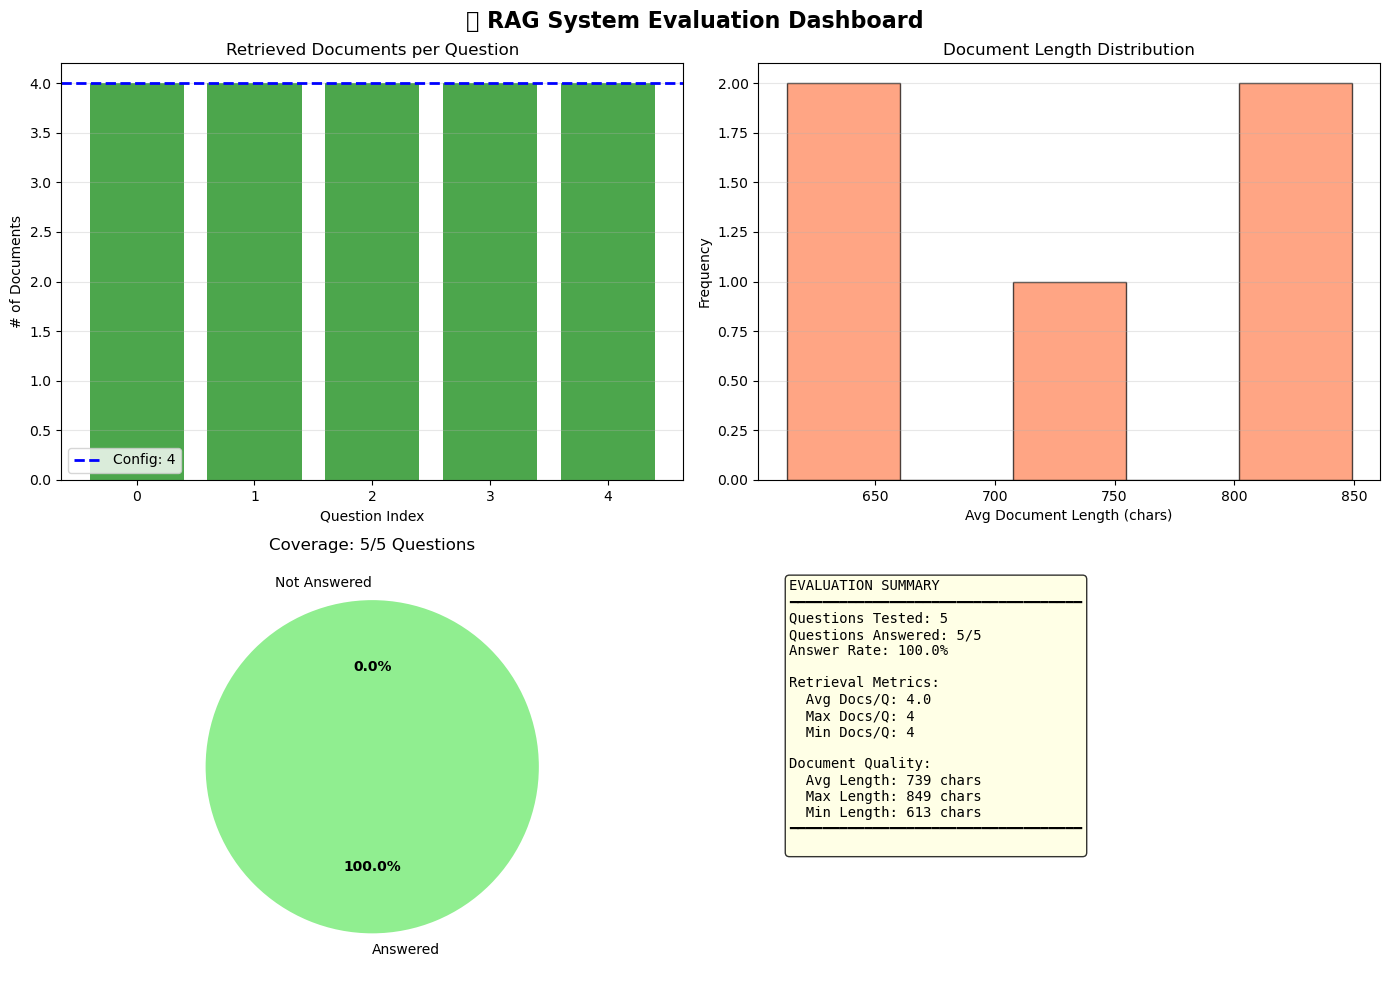

\n✅ Evaluation visualization complete!


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Create evaluation dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🤖 RAG System Evaluation Dashboard', fontsize=16, fontweight='bold')

# 1. Documents Retrieved Count
ax = axes[0, 0]
colors = ['green' if x > 0 else 'red' for x in eval_results['Docs_Retrieved']]
ax.bar(range(len(eval_results)), eval_results['Docs_Retrieved'], color=colors, alpha=0.7)
ax.axhline(y=TOP_K, color='blue', linestyle='--', linewidth=2, label=f'Config: {TOP_K}')
ax.set_xlabel('Question Index')
ax.set_ylabel('# of Documents')
ax.set_title('Retrieved Documents per Question')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Document Length Distribution  
ax = axes[0, 1]
ax.hist(eval_results['Avg_Doc_Length'], bins=max(5, len(eval_results)//2), 
        color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Avg Document Length (chars)')
ax.set_ylabel('Frequency')
ax.set_title('Document Length Distribution')
ax.grid(axis='y', alpha=0.3)

# 3. Question Coverage Pie
ax = axes[1, 0]
answered = int(eval_results['Has_Answer'].sum())
unanswered = len(eval_results) - answered
colors_pie = ['#90EE90', '#FFB6C6']
wedges, texts, autotexts = ax.pie([answered, unanswered], 
                                    labels=['Answered', 'Not Answered'],
                                    autopct='%1.1f%%',
                                    colors=colors_pie,
                                    startangle=90)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
ax.set_title(f'Coverage: {answered}/{len(eval_results)} Questions')

# 4. Metrics Summary
ax = axes[1, 1]
ax.axis('off')

summary_text = f'''EVALUATION SUMMARY
{'━' * 35}
Questions Tested: {len(eval_results)}
Questions Answered: {answered}/{len(eval_results)}
Answer Rate: {(answered/len(eval_results)*100):.1f}%

Retrieval Metrics:
  Avg Docs/Q: {eval_results['Docs_Retrieved'].mean():.1f}
  Max Docs/Q: {eval_results['Docs_Retrieved'].max():.0f}
  Min Docs/Q: {eval_results['Docs_Retrieved'].min():.0f}

Document Quality:
  Avg Length: {eval_results['Avg_Doc_Length'].mean():.0f} chars
  Max Length: {eval_results['Avg_Doc_Length'].max():.0f} chars
  Min Length: {eval_results['Avg_Doc_Length'].min():.0f} chars
{'━' * 35}
'''

ax.text(0.05, 0.95, summary_text, 
        fontsize=10, family='monospace',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print('\\n✅ Evaluation visualization complete!')

In [16]:
# Export evaluation results to files
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save to CSV
csv_filename = f'rag_evaluation_results_{timestamp}.csv'
eval_results.to_csv(csv_filename, index=False)
print(f'✅ CSV saved: {csv_filename}')

# Save comprehensive JSON report
json_report = {
    'timestamp': timestamp,
    'pipeline_config': {
        'chunk_size': CHUNK_SIZE,
        'chunk_overlap': CHUNK_OVERLAP,
        'top_k': TOP_K,
        'embedding_model': EMBED_MODEL,
        'llm_model': LLM_MODEL,
    },
    'summary': {
        'total_questions': len(eval_results),
        'questions_answered': int(eval_results['Has_Answer'].sum()),
        'coverage_rate': float((eval_results['Has_Answer'].sum() / len(eval_results)) * 100),
        'avg_docs_retrieved': float(eval_results['Docs_Retrieved'].mean()),
        'avg_doc_length': float(eval_results['Avg_Doc_Length'].mean()),
    },
    'results': eval_results.to_dict('records')
}

json_filename = f'rag_evaluation_report_{timestamp}.json'
with open(json_filename, 'w') as f:
    json.dump(json_report, f, indent=2)
print(f'✅ JSON report saved: {json_filename}')

print(f'\\n📂 You can download these files for further analysis!')

✅ CSV saved: rag_evaluation_results_20260615_233752.csv
✅ JSON report saved: rag_evaluation_report_20260615_233752.json
\n📂 You can download these files for further analysis!


### Why Use RAGAS?
✅ **Automatic Evaluation**: No manual annotation needed  
✅ **Holistic Metrics**: Evaluates retrieval, generation, and groundedness  
✅ **Reproducible**: Same results across runs  
✅ **Production-Ready**: Identify bottlenecks in your RAG pipeline  


---
## 🚀 Step 7 — Try It Out

In [17]:
# Single question with voice
ask('Where is this company located?')


────────────────────────────────────────────────────────────
🧑 Question : Where is this company located?
────────────────────────────────────────────────────────────
🤖 Answer   : The company, NovaTech Solutions Pvt. Ltd., is headquartered in Bangalore, India, and its registered office is located at Plot 42, Tech Park, Whitefield, Bangalore – 560066, Karnataka, India.
❌ TTS error: Failed to connect. Probable cause: Unknown


'The company, NovaTech Solutions Pvt. Ltd., is headquartered in Bangalore, India, and its registered office is located at Plot 42, Tech Park, Whitefield, Bangalore – 560066, Karnataka, India.'

In [18]:
# Show the retrieved context chunks alongside the answer
ask('What is the HR manual about?', show_context=True)


────────────────────────────────────────────────────────────
🧑 Question : What is the HR manual about?
────────────────────────────────────────────────────────────
🤖 Answer   : The HR manual is about the policies, procedures, and guidelines for NovaTech Solutions Pvt. Ltd., including standard operating procedures, employee acknowledgement, and employee management.

📎 Retrieved context chunks:
  [1] NovaTech Solutions  |  HR Manual v1.0 
 CONFIDENTIAL 
hr@novatechsolutions.in  |  +91-80-4567-8900 Page 16 
6 Final resolution communicated in writing to employee HR BP / 
CHRO 
Day 12–
15 
7 Follow-u ...
  [2] NovaTech Solutions  |  HR Manual v1.0 
 CONFIDENTIAL 
hr@novatechsolutions.in  |  +91-80-4567-8900 Page 11 
PART 4 — STANDARD OPERATING PROCEDURES (SOPs) 
 
SOP 4.1  Recruitment & Selection 
 
SOP: Re ...
  [3] NovaTech Solutions  |  HR Manual v1.0 
 CONFIDENTIAL 
hr@novatechsolutions.in  |  +91-80-4567-8900 Page 17 
PART 5 — EMPLOYEE ACKNOWLEDGEMENT 
 
I, the undersigned, confirm th

'The HR manual is about the policies, procedures, and guidelines for NovaTech Solutions Pvt. Ltd., including standard operating procedures, employee acknowledgement, and employee management.'

In [19]:
# Text-only mode — no audio
ask('What are the working hours?', speak = True)


────────────────────────────────────────────────────────────
🧑 Question : What are the working hours?
────────────────────────────────────────────────────────────
🤖 Answer   : Standard working hours are 9 hours per day, including a 1-hour lunch break (net 8 hours). Core hours are from 10:00 AM – 5:00 PM IST.


'Standard working hours are 9 hours per day, including a 1-hour lunch break (net 8 hours). Core hours are from 10:00 AM – 5:00 PM IST.'

In [20]:
# Batch mode — ask multiple questions in sequence
questions = [
    'Who is the CEO?',
    'What are the leave policies?',
    'What is the code of conduct?',
]

for q in questions:
    ask(q, speak=True)


────────────────────────────────────────────────────────────
🧑 Question : Who is the CEO?
────────────────────────────────────────────────────────────
🤖 Answer   : The CEO is not mentioned in the given context.



────────────────────────────────────────────────────────────
🧑 Question : What are the leave policies?
────────────────────────────────────────────────────────────
🤖 Answer   : According to the HR Manual v1.0, the leave policies are as follows:

- Earned Leave (EL): 18 days/year, can be carried forward up to 30 days and is encashable.
- Casual Leave (CL): 12 days/year, not encashable.
- Sick Leave (SL): 10 days/year, not encashable, but up to 3 days can be carried forward.
- Maternity Leave: 182 days, not encashable, applicable to female employees.
- Paternity Leave: 5 days, not encashable, applicable to male employees.
- Bereavement Leave: 3 days, not encashable, applicable to all employees.
- Compensatory Leave (Comp Off): as earned, can be carried forward up to 3 months and is not encashable.
- Study Leave: up to 10 days, not encashable, applicable to employees with 2 years of service.



────────────────────────────────────────────────────────────
🧑 Question : What is the code of conduct?
────────────────────────────────────────────────────────────
🤖 Answer   : The NovaTech Code of Conduct Policy establishes the behavioural standards expected of every NovaTech associate. It protects the reputation of the company, the safety of its employees, and the interests of its clients. The code of conduct includes the following:

- Employees shall conduct themselves professionally at all times.
- Consumption of alcohol or controlled substances during office hours or on company premises is strictly prohibited.
- Personal romantic relationships between a direct reporting manager and a subordinate must be disclosed to HR.
- Social media posts that identify NovaTech clients, projects, or internal financials without prior PR/Legal approval are prohibited.
- Employees must disclose any external employment, directorship, or financial interest that may conflict with NovaTech's interests

In [21]:
ask('How many employees does the company have?', speak = True)


────────────────────────────────────────────────────────────
🧑 Question : How many employees does the company have?
────────────────────────────────────────────────────────────
🤖 Answer   : I don't have that information.


"I don't have that information."